In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('data/online_retail_II.csv')
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [4]:
neg = df[df["Price"] < 0]

print("العدد:", len(neg))
print("بلا عميل:", neg["Customer ID"].isna().sum())
print()
print(neg[["Invoice", "StockCode", "Description", "Quantity",
           "Price", "Customer ID"]].to_string())

العدد: 5
بلا عميل: 5

        Invoice StockCode      Description  Quantity     Price  Customer ID
179403  A506401         B  Adjust bad debt         1 -53594.36          NaN
276274  A516228         B  Adjust bad debt         1 -44031.79          NaN
403472  A528059         B  Adjust bad debt         1 -38925.87          NaN
825444  A563186         B  Adjust bad debt         1 -11062.06          NaN
825445  A563187         B  Adjust bad debt         1 -11062.06          NaN


In [5]:
neg = df[(df["Price"] == 0) & df["Customer ID"].notna()]

print("العدد:", len(neg))
print("بلا عميل:", neg["Customer ID"].isna().sum())
print()
print(neg[["Invoice", "StockCode", "Description", "Quantity",
           "Price", "Customer ID"]].to_string())

العدد: 71
بلا عميل: 0

        Invoice StockCode                          Description  Quantity  Price  Customer ID
4674     489825     22076                   6 RIBBONS EMPIRE          12    0.0      16126.0
6781     489998     48185                  DOOR MAT FAIRY CAKE         2    0.0      15658.0
16107    490727         M                               Manual         1    0.0      17231.0
18738    490961     22065       CHRISTMAS PUDDING TRINKET POT          1    0.0      14108.0
18739    490961     22142         CHRISTMAS CRAFT WHITE FAIRY         12    0.0      14108.0
32916    492079     85042            ANTIQUE LILY FAIRY LIGHTS         8    0.0      15070.0
40101    492760     21143      ANTIQUE GLASS HEART DECORATION         12    0.0      18071.0
47126    493761     79320                      FLAMINGO LIGHTS        24    0.0      14258.0
48342    493899     22355          CHARLOTTE BAG , SUKI DESIGN        10    0.0      12417.0
57619    494607     21533            RETRO SPOT

In [6]:
d = df[df["Customer ID"].notna()]
neg_qty = d["Quantity"] < 0
is_c    = d["Invoice"].astype(str).str.startswith("C")

print("كمية سالبة:", neg_qty.sum())
print("فواتير C:", is_c.sum())
print("سالبة وليست C:", (neg_qty & ~is_c).sum())
print("C وليست سالبة:", (is_c & ~neg_qty).sum())

كمية سالبة: 18744
فواتير C: 18744
سالبة وليست C: 0
C وليست سالبة: 0


In [7]:
d = d.copy()
d["Invoice"] = d["Invoice"].astype(str).str.lstrip("C")
print(d["Invoice"].head())
print("لسا فيها حروف:", (~d["Invoice"].str.isdigit()).sum())

0    489434
1    489434
2    489434
3    489434
4    489434
Name: Invoice, dtype: str
لسا فيها حروف: 0


In [8]:
def clean(raw):
    d = raw.copy()

    # 1. التاريخ نوعاً زمنياً
    d["InvoiceDate"] = pd.to_datetime(d["InvoiceDate"])

    # 2. حذف الصفوف بلا عميل — خارج نطاق مسألة العملاء (~243 ألف)
    d = d[d["Customer ID"].notna()]
    d["Customer ID"] = d["Customer ID"].astype(int)

    # 3. الأسعار السالبة — قيود محاسبية لا مبيعات (5 صفوف، بلا عميل أصلاً)
    d = d[d["Price"] > 0]          # يُسقط الصفر أيضاً (71 صفاً، أثرها معدوم)

    # 4. المرتجعات تبقى، ووسمها بعمود صريح
    d["cancelled"] = d["Quantity"] < 0

    # 5. قيمة السطر — سالبة تلقائياً عند المرتجع
    d["amount"] = d["Quantity"] * d["Price"]

    d["Invoice"] = d["Invoice"].astype(str).str.lstrip("C").astype(int)

    return d

dc = clean(df)

print(dc.shape)
print("عملاء:", dc["Customer ID"].nunique())
print("مرتجعات:", dc["cancelled"].sum())
print("من:", dc["InvoiceDate"].min(), "إلى:", dc["InvoiceDate"].max())

(824293, 10)
عملاء: 5939
مرتجعات: 18744
من: 2009-12-01 07:45:00 إلى: 2011-12-09 12:50:00


In [9]:
inv = (dc.groupby(["Customer ID", "Invoice"])["InvoiceDate"]
         .min().reset_index()
         .sort_values(["Customer ID", "InvoiceDate"]))

gap = inv.groupby("Customer ID")["InvoiceDate"].diff().dt.days.dropna()

print("عدد الفجوات:", len(gap))
print(gap.describe(percentiles=[.25, .5, .75, .9]).round(1))
print()
print("عملاء بفاتورة واحدة:",
      (inv.groupby("Customer ID").size() == 1).sum(), "من", inv["Customer ID"].nunique())

عدد الفجوات: 38931
count    38931.0
mean        41.7
std         69.9
min          0.0
25%          3.0
50%         15.0
75%         48.0
90%        114.0
max        701.0
Name: InvoiceDate, dtype: float64

عملاء بفاتورة واحدة: 1458 من 5939


In [10]:
CUT = dc["InvoiceDate"].min() + pd.DateOffset(months=18)
print("القطع:", CUT)

hist = dc[dc["InvoiceDate"] <  CUT]    # فترة الملامح — 18 شهراً
fut  = dc[dc["InvoiceDate"] >= CUT]    # فترة الهدف — 6 أشهر

print(len(hist), len(fut))
print("عملاء في الماضي:", hist["Customer ID"].nunique())
print("عملاء في المستقبل:", fut["Customer ID"].nunique())

القطع: 2011-06-01 07:45:00
566553 257740
عملاء في الماضي: 4996
عملاء في المستقبل: 3576


In [11]:
W = 100
inv_h = (hist.groupby(["Customer ID", "Invoice"])
              .agg(date=("InvoiceDate", "min"), amt=("amount", "sum"))
              .reset_index().sort_values(["Customer ID", "date"]))

g = inv_h.groupby("Customer ID")

feat = pd.DataFrame({
    "n_inv":    g.size(),
    "total":    g["amt"].sum(),
    "avg_inv":  g["amt"].mean(),
    "recency":  (CUT - g["date"].max()).dt.days,
    "tenure":   (CUT - g["date"].min()).dt.days,
    "avg_gap":  g["date"].apply(lambda s: s.diff().dt.days.mean()),
})

feat["rate"]      = feat["total"] / feat["tenure"].clip(lower=1)
feat["rec_ratio"] = feat["recency"] / feat["avg_gap"]

# الاتجاه — آخر 100 يوم مقابل الـ 100 التي قبلها
w1 = inv_h[inv_h["date"] >= CUT - pd.Timedelta(days=W)]
w2 = inv_h[(inv_h["date"] >= CUT - pd.Timedelta(days=2*W)) &
           (inv_h["date"] <  CUT - pd.Timedelta(days=W))]

feat["amt_w1"] = w1.groupby("Customer ID")["amt"].sum()
feat["amt_w2"] = w2.groupby("Customer ID")["amt"].sum()
feat["cnt_w1"] = w1.groupby("Customer ID").size()
feat["cnt_w2"] = w2.groupby("Customer ID").size()
feat[["amt_w1","amt_w2","cnt_w1","cnt_w2"]] = feat[["amt_w1","amt_w2","cnt_w1","cnt_w2"]].fillna(0)

feat["trend_amt"] = feat["amt_w1"] - feat["amt_w2"]
feat["trend_cnt"] = feat["cnt_w1"] - feat["cnt_w2"]

# المرتجعات
r = hist[hist["cancelled"]].groupby("Customer ID")
feat["n_ret"]   = r.size()
feat["ret_amt"] = r["amount"].sum().abs()
feat[["n_ret","ret_amt"]] = feat[["n_ret","ret_amt"]].fillna(0)
feat["ret_ratio"] = feat["ret_amt"] / feat["total"].abs().clip(lower=1)

# الهدف
feat["target"] = fut.groupby("Customer ID")["amount"].sum()
feat["target"] = feat["target"].fillna(0)

print(feat.shape)
print(feat.head())

(4996, 18)
             n_inv    total     avg_inv  recency  tenure     avg_gap  \
Customer ID                                                            
12346           17   -64.68   -3.804706      133     533   24.562500   
12347            4  3146.75  786.687500       54     212   52.000000   
12348            4  1709.40  427.350000       56     246   63.000000   
12349            4  2646.99  661.747500      215     543  108.666667   
12350            1   334.40  334.400000      118     118         NaN   

                  rate  rec_ratio  amt_w1   amt_w2  cnt_w1  cnt_w2  trend_amt  \
Customer ID                                                                     
12346        -0.121351   5.414758    0.00     0.00     0.0     2.0       0.00   
12347        14.843160   1.038462  636.25  1898.97     1.0     2.0   -1262.72   
12348         6.948780   0.888889  367.00  1120.24     1.0     2.0    -753.24   
12349         4.874751   1.978528    0.00     0.00     0.0     0.0       0.00  

In [12]:
buy = hist[~hist["cancelled"]].groupby("Customer ID")["amount"].sum()
feat["gross"] = buy
feat["gross"] = feat["gross"].fillna(0)

feat["ret_ratio"] = feat["ret_amt"] / feat["gross"].clip(lower=1)

print(feat["ret_ratio"].describe().round(3))
print()
print("total سالب:", (feat["total"] < 0).sum())
print("total قريب صفر (<10):", (feat["total"].between(0, 10)).sum())
print("ret_ratio > 0.9:", (feat["ret_ratio"] > 0.9).sum())

count     4996.000
mean        12.486
std        385.025
min          0.000
25%          0.000
50%          0.000
75%          0.018
max      25111.090
Name: ret_ratio, dtype: float64

total سالب: 86
total قريب صفر (<10): 18
ret_ratio > 0.9: 100


In [13]:
bad = feat[feat["ret_ratio"] > 0.9].index[:3]

for c in bad:
    rows = dc[dc["Customer ID"] == c].sort_values("InvoiceDate")
    print(f"=== العميل {c} | صفوف: {len(rows)} | gross={feat.loc[c,'gross']:.1f}"
          f" | total={feat.loc[c,'total']:.1f} ===")
    print(rows[["Invoice", "InvoiceDate", "Quantity", "Price",
                "amount", "cancelled"]].head(12).to_string(index=False))
    print()

=== العميل 12346 | صفوف: 48 | gross=77556.5 | total=-64.7 ===
 Invoice         InvoiceDate  Quantity  Price  amount  cancelled
  491725 2009-12-14 08:34:00        10   4.50   45.00      False
  491742 2009-12-14 11:00:00         5   4.50   22.50      False
  491744 2009-12-14 11:02:00         5   4.50   22.50      False
  492718 2009-12-18 10:47:00         5   4.50   22.50      False
  492722 2009-12-18 10:55:00         1   1.00    1.00      False
  493410 2010-01-04 09:24:00         5   4.50   22.50      False
  493412 2010-01-04 09:53:00         5   4.50   22.50      False
  494450 2010-01-14 13:50:00         5   4.50   22.50      False
  495295 2010-01-22 13:30:00         5   4.50   22.50      False
  495800 2010-01-26 17:27:00        -1 103.50 -103.50       True
  499763 2010-03-02 13:08:00         1   5.95    5.95      False
  499763 2010-03-02 13:08:00         1   5.95    5.95      False

=== العميل 12382 | صفوف: 1 | gross=0.0 | total=-18.4 ===
 Invoice         InvoiceDate  Quant

In [14]:
before = len(feat)
feat = feat[feat["gross"] > 0]

print("حُذف:", before - len(feat), "| بقي:", len(feat))
print("total سالب بعد الحذف:", (feat["total"] < 0).sum())
print("ret_ratio أقصى:", round(feat["ret_ratio"].max(), 2))

حُذف: 63 | بقي: 4933
total سالب بعد الحذف: 23
ret_ratio أقصى: 3.1


In [15]:
has_ret = feat[feat["n_ret"] > 0]

print("عملاء لهم مرتجعات:", len(has_ret), "من", len(feat),
      f"({len(has_ret)/len(feat)*100:.1f}%)")
print()
print("منهم total سالب:", (has_ret["total"] < 0).sum(),
      f"({(has_ret['total']<0).sum()/len(has_ret)*100:.1f}%)")
print("منهم ret_ratio > 1:", (has_ret["ret_ratio"] > 1).sum())
print()
print(has_ret["ret_ratio"].describe(percentiles=[.5, .9, .99]).round(3))


عملاء لهم مرتجعات: 2061 من 4933 (41.8%)

منهم total سالب: 23 (1.1%)
منهم ret_ratio > 1: 22

count    2061.000
mean        0.082
std         0.225
min         0.000
50%         0.024
90%         0.154
99%         1.067
max         3.103
Name: ret_ratio, dtype: float64


In [16]:
before = len(feat)
feat = feat[feat["ret_ratio"] <= 1]

print("حُذف:", before - len(feat), "| بقي:", len(feat))
print("total سالب:", (feat["total"] < 0).sum())
print("ret_ratio أقصى:", round(feat["ret_ratio"].max(), 3))
print("avg_gap فارغ:", feat["avg_gap"].isna().sum())

حُذف: 22 | بقي: 4911
total سالب: 1
ret_ratio أقصى: 1.0
avg_gap فارغ: 1304


In [17]:
print(feat["target"].describe(percentiles=[.5, .75, .9, .95, .99]).round(1))
print()
print("هدفهم صفر:", (feat["target"] <= 0).sum(), f"({(feat['target']<=0).mean()*100:.1f}%)")
print("أعلى 1% يشكّلون من الإيراد:",
      round(feat["target"].nlargest(int(len(feat)*0.01)).sum() / feat["target"].sum() * 100, 1), "%")

count      4911.0
mean        903.3
std        5144.7
min       -4287.6
50%         110.8
75%         697.3
90%        1832.5
95%        3157.4
99%        9556.3
max      191954.6
Name: target, dtype: float64

هدفهم صفر: 2321 (47.3%)
أعلى 1% يشكّلون من الإيراد: 36.5 %


In [18]:
feat["returned"] = feat.index.isin(fut["Customer ID"].unique()).astype(int)

print(feat["returned"].value_counts())
print("متوسط الهدف عند العائدين:", round(feat.loc[feat.returned==1,"target"].mean(), 1))

returned
1    2628
0    2283
Name: count, dtype: int64
متوسط الهدف عند العائدين: 1687.9


In [20]:
from sklearn.model_selection import train_test_split

FEATS = ["n_inv", "total", "gross", "avg_inv", "recency", "tenure",
"avg_gap", "rate", "rec_ratio",
"amt_w1", "amt_w2", "cnt_w1","cnt_w2", "trend_amt", "trend_cnt",
"n_ret", "ret_amt", "ret_ratio"]

X = feat[FEATS]
y_cls = feat["returned"]
y_reg = feat["target"]

idx_tr, idx_te = train_test_split(
feat.index, test_size=0.2, random_state=42, stratify=y_cls)

print(len(idx_tr), len(idx_te))
print("نسبة العائدين", round(y_cls[idx_tr].mean(), 3), round(y_cls[idx_te].mean(), 3))



3928 983
نسبة العائدين 0.535 0.535


In [21]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

clf = HistGradientBoostingClassifier(random_state=42)
clf.fit(X.loc[idx_tr], y_cls[idx_tr])

p = clf.predict(X.loc[idx_te])
proba = clf.predict_proba(X.loc[idx_te])[:, 1]

print(confusion_matrix(y_cls[idx_te], p))
print(classification_report(y_cls[idx_te], p, digits=3))
print("AUC:", round(roc_auc_score(y_cls[idx_te], proba), 3))

[[331 126]
 [161 365]]
              precision    recall  f1-score   support

           0      0.673     0.724     0.698       457
           1      0.743     0.694     0.718       526

    accuracy                          0.708       983
   macro avg      0.708     0.709     0.708       983
weighted avg      0.711     0.708     0.708       983

AUC: 0.798


In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

Xtr, ytr = X.loc[idx_tr], y_cls[idx_tr]
Xte, yte = X.loc[idx_te], y_cls[idx_te]

grid = {
    "max_iter":         [200, 400],
    "learning_rate":    [0.03, 0.05, 0.1],
    "max_leaf_nodes":   [15, 31],
    "min_samples_leaf": [20, 50],
    "l2_regularization":[0, 1.0],
}

gs = GridSearchCV(HistGradientBoostingClassifier(random_state=42),
                  grid, scoring="roc_auc", cv=3, n_jobs=-1, verbose=1)
gs.fit(Xtr, ytr)

print(gs.best_params_)
print("AUC (cv):", round(gs.best_score_, 4))
print("AUC (test):", round(roc_auc_score(yte, gs.best_estimator_.predict_proba(Xte)[:,1]), 4))

Fitting 3 folds for each of 48 candidates, totalling 144 fits


{'l2_regularization': 0, 'learning_rate': 0.03, 'max_iter': 200, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}
AUC (cv): 0.8074
AUC (test): 0.8083


In [23]:
Wr = 100

first_ret = (hist[hist["cancelled"]]
             .groupby("Customer ID")["InvoiceDate"].min()
             .rename("ret_date"))

iv = inv_h.merge(first_ret, on="Customer ID", how="inner")

pre  = iv[(iv["date"] <  iv["ret_date"]) &
          (iv["date"] >= iv["ret_date"] - pd.Timedelta(days=Wr))]
post = iv[(iv["date"] >  iv["ret_date"]) &
          (iv["date"] <= iv["ret_date"] + pd.Timedelta(days=Wr))]

feat["ret_amt_pre"]  = pre.groupby("Customer ID")["amt"].sum()
feat["ret_amt_post"] = post.groupby("Customer ID")["amt"].sum()
feat["ret_cnt_pre"]  = pre.groupby("Customer ID").size()
feat["ret_cnt_post"] = post.groupby("Customer ID").size()

has = feat.index.isin(first_ret.index)
for c in ["ret_amt_pre","ret_amt_post","ret_cnt_pre","ret_cnt_post"]:
    feat.loc[has, c] = feat.loc[has, c].fillna(0)

feat["ret_shock_amt"] = feat["ret_amt_post"] - feat["ret_amt_pre"]
feat["ret_shock_cnt"] = feat["ret_cnt_post"] - feat["ret_cnt_pre"]

print(feat[["ret_shock_amt","ret_shock_cnt"]].describe().round(1))
print("فارغ:", feat["ret_shock_amt"].isna().sum())

       ret_shock_amt  ret_shock_cnt
count         2039.0         2039.0
mean           -33.7            0.8
std           2644.3            3.6
min         -41781.5           -8.0
25%           -458.7           -1.0
50%           -155.0            0.0
75%            235.0            2.0
max          75918.0           55.0
فارغ: 2872


In [24]:
FEATS2 = FEATS + ["ret_shock_amt", "ret_shock_cnt"]
X2 = feat[FEATS2]

m = HistGradientBoostingClassifier(
    random_state=42, l2_regularization=0, learning_rate=0.03,
    max_iter=200, max_leaf_nodes=15, min_samples_leaf=20
)
m.fit(X2.loc[idx_tr], y_cls[idx_tr])

auc = roc_auc_score(y_cls[idx_te], m.predict_proba(X2.loc[idx_te])[:,1])
print("AUC مع الملمح:", round(auc, 4), "| بدونه: 0.8083")

AUC مع الملمح: 0.8082 | بدونه: 0.8083


In [25]:
buys = hist[~hist["cancelled"]]
gb = buys.groupby("Customer ID")

feat["n_sku"]  = gb["StockCode"].nunique()
feat["n_sku"]  = feat["n_sku"].fillna(0)

feat["sku_per_inv"] = feat["n_sku"] / feat["n_inv"].clip(lower=1)

rep = (buys.groupby(["Customer ID", "StockCode"])["Invoice"].nunique()
           .groupby("Customer ID").apply(lambda s: (s > 1).mean()))
feat["repeat_sku"] = rep
feat["repeat_sku"] = feat["repeat_sku"].fillna(0)

print(feat[["n_sku", "sku_per_inv", "repeat_sku"]].describe().round(2))

         n_sku  sku_per_inv  repeat_sku
count  4911.00      4911.00     4911.00
mean     70.43        15.66        0.15
std      97.47        14.54        0.19
min       1.00         0.06        0.00
25%      17.00         6.44        0.00
50%      40.00        12.00        0.08
75%      87.00        20.00        0.24
max    1978.00       220.00        1.00


In [26]:
FEATS3 = FEATS + ["n_sku", "sku_per_inv", "repeat_sku"]
X3 = feat[FEATS3]

m3 = HistGradientBoostingClassifier(
    random_state=42, l2_regularization=0, learning_rate=0.03,
    max_iter=200, max_leaf_nodes=15, min_samples_leaf=20
)
m3.fit(X3.loc[idx_tr], y_cls[idx_tr])

auc3 = roc_auc_score(y_cls[idx_te], m3.predict_proba(X3.loc[idx_te])[:,1])
print("AUC مع التنوّع:", round(auc3, 4), "| الأساس: 0.8083")

AUC مع التنوّع: 0.8098 | الأساس: 0.8083


In [27]:
grid = {
    "max_iter":          [200, 400, 600],
    "learning_rate":     [0.02, 0.03, 0.05],
    "max_leaf_nodes":    [7, 15, 31],
    "min_samples_leaf":  [20, 40, 80],
    "l2_regularization": [0, 0.5, 2.0],
}

gs3 = GridSearchCV(HistGradientBoostingClassifier(random_state=42),
                   grid, scoring="roc_auc", cv=3, n_jobs=-1, verbose=1)
gs3.fit(X3.loc[idx_tr], y_cls[idx_tr])

print(gs3.best_params_)
print("AUC (cv):", round(gs3.best_score_, 4))
print("AUC (test):", round(roc_auc_score(y_cls[idx_te],
      gs3.best_estimator_.predict_proba(X3.loc[idx_te])[:,1]), 4))

Fitting 3 folds for each of 243 candidates, totalling 729 fits
{'l2_regularization': 0.5, 'learning_rate': 0.02, 'max_iter': 200, 'max_leaf_nodes': 7, 'min_samples_leaf': 20}
AUC (cv): 0.8155
AUC (test): 0.809


In [28]:
from sklearn.ensemble import HistGradientBoostingRegressor

ret_tr = idx_tr[y_cls[idx_tr] == 1]        # العائدون من التدريب فقط
print("عائدون بالتدريب:", len(ret_tr))

reg = HistGradientBoostingRegressor(random_state=42)
reg.fit(X3.loc[ret_tr], y_reg[ret_tr])

# التنبؤ على كل الاختبار — لا العائدين فقط
amt_pred = reg.predict(X3.loc[idx_te])
prob     = gs3.best_estimator_.predict_proba(X3.loc[idx_te])[:, 1]

expected = prob * amt_pred        # القيمة المتوقعة = احتمال العودة × المبلغ

print(pd.Series(expected).describe().round(1))

عائدون بالتدريب: 2102
count      983.0
mean       709.3
std       2016.2
min      -1439.0
25%        112.6
50%        267.6
75%        648.5
max      44367.2
dtype: float64


In [29]:
res = pd.DataFrame({
    "pred": expected,
    "true": y_reg[idx_te].values
}, index=idx_te)

for k in [50, 100, 200]:
    top = res.nlargest(k, "pred")
    rand = res["true"].mean() * k
    print(f"أعلى {k:>3} بالتنبؤ | إيراد فعلي: {top['true'].sum():>10,.0f}"
          f" | عشوائي: {rand:>9,.0f}"
          f" | نسبة من الإجمالي: {top['true'].sum()/res['true'].sum()*100:>5.1f}%")

print()
print("إجمالي الإيراد الفعلي بالاختبار:", f"{res['true'].sum():,.0f}")

أعلى  50 بالتنبؤ | إيراد فعلي:    216,093 | عشوائي:    32,552 | نسبة من الإجمالي:  33.8%
أعلى 100 بالتنبؤ | إيراد فعلي:    308,606 | عشوائي:    65,104 | نسبة من الإجمالي:  48.2%
أعلى 200 بالتنبؤ | إيراد فعلي:    409,103 | عشوائي:   130,207 | نسبة من الإجمالي:  63.9%

إجمالي الإيراد الفعلي بالاختبار: 639,969


  5% من العملاء →  33.6% من الإيراد
 10% من العملاء →  48.2% من الإيراد
 20% من العملاء →  63.0% من الإيراد
 30% من العملاء →  75.8% من الإيراد
 50% من العملاء →  87.9% من الإيراد


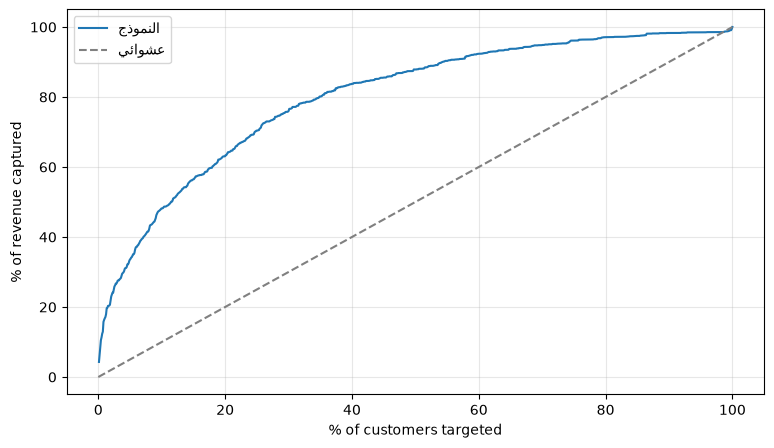

In [30]:
import matplotlib.pyplot as plt
import numpy as np

r = res.sort_values("pred", ascending=False)
cum = r["true"].cumsum() / r["true"].sum() * 100
x   = np.arange(1, len(r) + 1) / len(r) * 100

plt.figure(figsize=(9, 5))
plt.plot(x, cum, label="النموذج")
plt.plot([0, 100], [0, 100], "--", color="gray", label="عشوائي")
plt.xlabel("% of customers targeted")
plt.ylabel("% of revenue captured")
plt.legend()
plt.grid(alpha=.3)

for p in [5, 10, 20, 30, 50]:
    i = int(len(r) * p / 100) - 1
    print(f"{p:>3}% من العملاء → {cum.iloc[i]:>5.1f}% من الإيراد")

In [31]:
from sklearn.inspection import permutation_importance

best = gs3.best_estimator_
imp = permutation_importance(
    best, X3.loc[idx_te], y_cls[idx_te],
    scoring="roc_auc", n_repeats=10, random_state=42, n_jobs=-1
)

s = (pd.Series(imp.importances_mean, index=X3.columns)
       .sort_values(ascending=False))
print(s.round(4).to_string())


recency        0.0290
amt_w1         0.0161
rec_ratio      0.0102
avg_gap        0.0074
rate           0.0061
n_sku          0.0026
repeat_sku     0.0022
total          0.0020
n_inv          0.0012
ret_ratio      0.0010
gross          0.0010
cnt_w1         0.0004
trend_cnt      0.0001
ret_amt        0.0000
n_ret          0.0000
avg_inv       -0.0000
tenure        -0.0000
trend_amt     -0.0001
amt_w2        -0.0001
cnt_w2        -0.0003
sku_per_inv   -0.0006


In [32]:
KEEP = ["recency", "amt_w1", "rec_ratio", "avg_gap", "rate",
        "n_sku", "repeat_sku", "total", "n_inv", "ret_ratio",
        "gross", "cnt_w1", "trend_cnt"]

X4 = feat[KEEP]

m4 = HistGradientBoostingClassifier(
    random_state=42, l2_regularization=0.5, learning_rate=0.02,
    max_iter=200, max_leaf_nodes=7, min_samples_leaf=20
)
m4.fit(X4.loc[idx_tr], y_cls[idx_tr])
prob4 = m4.predict_proba(X4.loc[idx_te])[:, 1]
print("AUC:", round(roc_auc_score(y_cls[idx_te], prob4), 4), "| قبل: 0.809")

# القياس الحقيقي — تغطية الإيراد
reg4 = HistGradientBoostingRegressor(random_state=42)
reg4.fit(X4.loc[ret_tr], y_reg[ret_tr])
exp4 = prob4 * reg4.predict(X4.loc[idx_te])

r4 = pd.DataFrame({"pred": exp4, "true": y_reg[idx_te].values}, index=idx_te)
for p in [5, 10, 20]:
    k = int(len(r4) * p / 100)
    print(f"{p}% → {r4.nlargest(k,'pred')['true'].sum()/r4['true'].sum()*100:.1f}%"
          f" | قبل: {[33.6, 48.2, 63.0][[5,10,20].index(p)]}%")

AUC: 0.81 | قبل: 0.809
5% → 32.0% | قبل: 33.6%
10% → 45.9% | قبل: 48.2%
20% → 62.8% | قبل: 63.0%


In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

Xr, yr = X3.loc[ret_tr], y_reg[ret_tr]

grid_r = {
    "max_iter":          [200, 400],
    "learning_rate":     [0.02, 0.05, 0.1],
    "max_leaf_nodes":    [7, 15, 31],
    "min_samples_leaf":  [10, 20, 50],
    "l2_regularization": [0, 1.0],
}

gsr = GridSearchCV(HistGradientBoostingRegressor(random_state=42),
                   grid_r, scoring="neg_mean_absolute_error",
                   cv=3, n_jobs=-1, verbose=1)
gsr.fit(Xr, yr)
print(gsr.best_params_)

exp5 = prob * gsr.best_estimator_.predict(X3.loc[idx_te])

Fitting 3 folds for each of 108 candidates, totalling 324 fits
{'l2_regularization': 1.0, 'learning_rate': 0.02, 'max_iter': 200, 'max_leaf_nodes': 15, 'min_samples_leaf': 10}


In [35]:
import joblib, json

joblib.dump({
    "clf":   gs3.best_estimator_,
    "reg":   gsr.best_estimator_,
    "feats": FEATS3,
    "cut":   str(CUT),
}, "models/clv_retail.joblib")

with open("models/clv_retail_meta.json", "w", encoding="utf-8") as f:
    json.dump({
        "auc": 0.809,
        "coverage": {"5%": 33.6, "10%": 48.2, "20%": 63.0},
        "n_customers": len(feat),
        "window": "18 شهراً ملامح / 6 أشهر هدف",
    }, f, ensure_ascii=False, indent=2)

print("تم")

تم


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

RFM = ["recency", "n_inv", "total"]
Z = feat[RFM].copy()

print(Z.describe().round(1))
print()
print("total ملتوٍ:", round(Z["total"].skew(), 2), "| n_inv:", round(Z["n_inv"].skew(), 2))

       recency   n_inv     total
count   4911.0  4911.0    4911.0
mean     165.5     6.4    2354.8
std      140.9    12.6   10479.9
min        0.0     1.0      -0.0
25%       42.0     1.0     310.9
50%      142.0     3.0     750.6
75%      239.0     7.0    1956.0
max      546.0   336.0  406260.6

total ملتوٍ: 24.37 | n_inv: 10.57


In [37]:
import numpy as np

Z = feat[RFM].copy()
Z["n_inv"] = np.log1p(Z["n_inv"])
Z["total"] = np.log1p(Z["total"].clip(lower=0))

print("الالتواء بعد اللوغاريتم:")
print("n_inv:", round(Z["n_inv"].skew(), 2), "| total:", round(Z["total"].skew(), 2))

Zs = StandardScaler().fit_transform(Z)
print("\nبعد التحجيم — المتوسط والانحراف:")
print(pd.DataFrame(Zs, columns=RFM).describe().round(2).loc[["mean","std","min","max"]])

الالتواء بعد اللوغاريتم:
n_inv: 0.96 | total: -0.02

بعد التحجيم — المتوسط والانحراف:
      recency  n_inv  total
mean    -0.00  -0.00   0.00
std      1.00   1.00   1.00
min     -1.17  -1.08  -4.86
max      2.70   5.23   4.55


k=2 | inertia=     7493 | silhouette=0.416
k=3 | inertia=     5305 | silhouette=0.357
k=4 | inertia=     4156 | silhouette=0.331
k=5 | inertia=     3458 | silhouette=0.336
k=6 | inertia=     2974 | silhouette=0.333
k=7 | inertia=     2645 | silhouette=0.320
k=8 | inertia=     2388 | silhouette=0.322


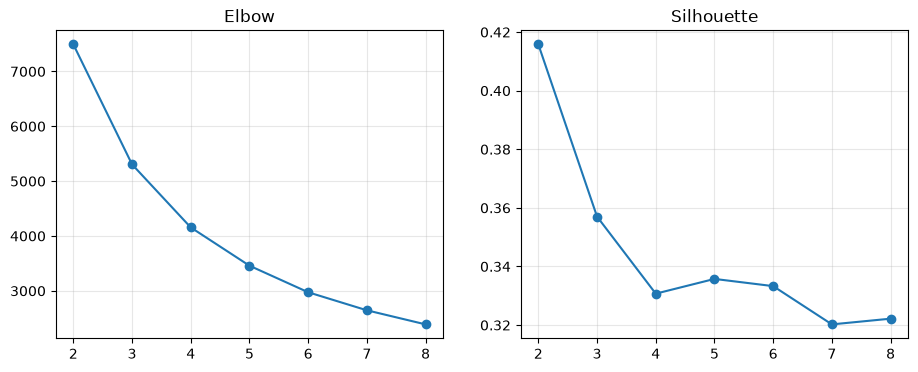

In [38]:
from sklearn.metrics import silhouette_score

ks, inertias, sils = range(2, 9), [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Zs)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Zs, km.labels_))
    print(f"k={k} | inertia={km.inertia_:>9.0f} | silhouette={sils[-1]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(ks), inertias, "o-"); ax[0].set_title("Elbow"); ax[0].grid(alpha=.3)
ax[1].plot(list(ks), sils, "o-");     ax[1].set_title("Silhouette"); ax[1].grid(alpha=.3)

In [39]:
km = KMeans(n_clusters=5, random_state=42, n_init=10).fit(Zs)
feat["seg"] = km.labels_

prof = feat.groupby("seg").agg(
    n=("recency", "size"),
    recency=("recency", "median"),
    n_inv=("n_inv", "median"),
    total=("total", "median"),
    returned=("returned", "mean"),
    future=("target", "median"),
).round(2)

prof["revenue_share"] = (feat.groupby("seg")["target"].sum()
                         / feat["target"].sum() * 100).round(1)
print(prof)

        n  recency  n_inv    total  returned   future  revenue_share
seg                                                                 
0    1008    222.0    3.0   900.41      0.45     0.00            7.1
1    1279    121.0    1.0   299.53      0.41     0.00            5.9
2     610     19.0   18.0  5873.90      0.93  1921.68           64.0
3    1257     48.0    6.0  1646.27      0.78   470.08           22.0
4     757    406.0    1.0   215.53      0.15     0.00            1.0


In [41]:
NAMES = {2: "النخبة", 3: "أوفياء متوسطون", 0: "نائمون",
         1: "عابرون جدد", 4: "خاملون"}

act = pd.DataFrame({
    "seg":       feat.loc[idx_te, "seg"],
    "p_leave":   1 - prob,
    "value":     gsr.best_estimator_.predict(X3.loc[idx_te]),
    "true":      y_reg[idx_te],
}, index=idx_te)

act["risk"] = act["p_leave"] * act["value"].clip(lower=0)

top_per_seg = (act.sort_values("risk", ascending=False)
                  .groupby("seg").head(10))


for s in [2, 3, 0, 1, 4]:
    g = top_per_seg[top_per_seg["seg"] == s]
    print(f"\n=== {NAMES[s]} (seg {s}) — أعلى 10 خطراً ===")
    print(f"متوسط احتمال المغادرة: {g['p_leave'].mean():.2f}"
          f" | القيمة المعرّضة: {g['risk'].sum():,.0f}"
          f" | ما أنفقوه فعلاً: {g['true'].sum():,.0f}")


=== النخبة (seg 2) — أعلى 10 خطراً ===
متوسط احتمال المغادرة: 0.17 | القيمة المعرّضة: 6,839 | ما أنفقوه فعلاً: 57,792

=== أوفياء متوسطون (seg 3) — أعلى 10 خطراً ===
متوسط احتمال المغادرة: 0.34 | القيمة المعرّضة: 7,616 | ما أنفقوه فعلاً: 13,451

=== نائمون (seg 0) — أعلى 10 خطراً ===
متوسط احتمال المغادرة: 0.63 | القيمة المعرّضة: 30,176 | ما أنفقوه فعلاً: 1,550

=== عابرون جدد (seg 1) — أعلى 10 خطراً ===
متوسط احتمال المغادرة: 0.47 | القيمة المعرّضة: 9,694 | ما أنفقوه فعلاً: 1,534

=== خاملون (seg 4) — أعلى 10 خطراً ===
متوسط احتمال المغادرة: 0.83 | القيمة المعرّضة: 4,641 | ما أنفقوه فعلاً: 0


In [42]:
from sklearn.metrics import mean_absolute_error

# المرحلة 1 — التصنيف
c = gs3.best_estimator_
auc_tr = roc_auc_score(y_cls[idx_tr], c.predict_proba(X3.loc[idx_tr])[:,1])
auc_te = roc_auc_score(y_cls[idx_te], c.predict_proba(X3.loc[idx_te])[:,1])
acc_tr = (c.predict(X3.loc[idx_tr]) == y_cls[idx_tr]).mean()
acc_te = (c.predict(X3.loc[idx_te]) == y_cls[idx_te]).mean()

print("=== التصنيف ===")
print(f"AUC  | تدريب {auc_tr:.4f} | اختبار {auc_te:.4f} | فجوة {auc_tr-auc_te:+.4f}")
print(f"Acc  | تدريب {acc_tr:.4f} | اختبار {acc_te:.4f} | فجوة {acc_tr-acc_te:+.4f}")

# المرحلة 2 — الانحدار (العائدون فقط، بالطرفين)
r = gsr.best_estimator_
ret_te = idx_te[y_cls[idx_te] == 1]

mae_tr = mean_absolute_error(y_reg[ret_tr], r.predict(X3.loc[ret_tr]))
mae_te = mean_absolute_error(y_reg[ret_te], r.predict(X3.loc[ret_te]))

print("\n=== الانحدار ===")
print(f"MAE  | تدريب {mae_tr:,.0f} | اختبار {mae_te:,.0f} | نسبة {mae_te/mae_tr:.2f}×")

=== التصنيف ===
AUC  | تدريب 0.8449 | اختبار 0.8090 | فجوة +0.0359
Acc  | تدريب 0.7599 | اختبار 0.7253 | فجوة +0.0346

=== الانحدار ===
MAE  | تدريب 824 | اختبار 673 | نسبة 0.82×
